In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")

# Load data
df = pd.read_csv('benchmark_results.csv')

# Clean RMSD: remove ' nm' and convert to float
df['RMSD'] = df['RMSD'].astype(str).str.replace(' nm', '', regex=False)
df['RMSD'] = pd.to_numeric(df['RMSD'], errors='coerce')

# Define terms
# n-mer: number of chains
# homomer: Number of chain types == 1
# complete heteromer: Number of chain types == Number of chains
# partial heteromer: Number of chain types < Number of chains and != 1
df['Complex_Type'] = 'Unknown'
df.loc[df['Number of chain types in PDB'] == 1, 'Complex_Type'] = 'Homomer'
df.loc[df['Number of chain types in PDB'] == df['Number of chains in PDB'], 'Complex_Type'] = 'Complete Heteromer'
mask_partial = (df['Number of chain types in PDB'] < df['Number of chains in PDB']) & (df['Number of chain types in PDB'] != 1)
df.loc[mask_partial, 'Complex_Type'] = 'Partial Heteromer'

# Heterogeneity
# homogenity = (number of chain types - 1) / (number of chains - 1)
df['Heterogeneity'] = np.where(
    df['Number of chains in PDB'] > 1,
    (df['Number of chain types in PDB'] - 1) / (df['Number of chains in PDB'] - 1),
    np.nan
)

df.head()

,PDB ID,Number of chains in PDB,Number of chain types in PDB,Status,RMSD,Complex_Type,Heterogeneity
0,7cqv,3,2,DC,NaN,Partial Heteromer,0.5
1,11hn,3,1,Success,0.0000,Homomer,0.0
2,6y66,5,1,Success,0.0073,Homomer,0.0
3,6gbn,4,1,Success,0.0384,Homomer,0.0
4,6gbq,4,1,DC,NaN,Homomer,0.0


### 1. Simple statistics of Status %, Status number, and RMSD mean/STD by type

In [256]:
print("--- Status Statistics ---")
print("Total records:", len(df))
status_counts = df['Status'].value_counts()
status_pct = df['Status'].value_counts(normalize=True) * 100
stats_df = pd.DataFrame({'Count': status_counts, 'Percentage (%)': status_pct})
print(stats_df)
print("\n--- RMSD Statistics (Success only) ---")
success_df = df[df['Status'] == 'Success']
print("All data - Mean: {:.4f}, STD: {:.4f}".format(success_df['RMSD'].mean(), success_df['RMSD'].std()))

for ctype in ['Homomer', 'Complete Heteromer', 'Partial Heteromer']:
    sub_df = success_df[success_df['Complex_Type'] == ctype]
    print("{} - Mean: {:.4f}, STD: {:.4f}".format(ctype, sub_df['RMSD'].mean(), sub_df['RMSD'].std()))

--- Status Statistics ---
Total records: 44701
         Count  Percentage (%)
Status                        
Success  31330       70.087917
DC       11689       26.149303
FP        1099        2.458558
UA         583        1.304221

--- RMSD Statistics (Success only) ---
All data - Mean: 0.3327, STD: 0.6728
Homomer - Mean: 0.3814, STD: 0.6554
Complete Heteromer - Mean: 0.0000, STD: 0.0000
Partial Heteromer - Mean: 0.4828, STD: 0.9264


### Combined Plot: Success Rate, RMSD, and Heterogeneity vs Number of Chains


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_38599/3487343933.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


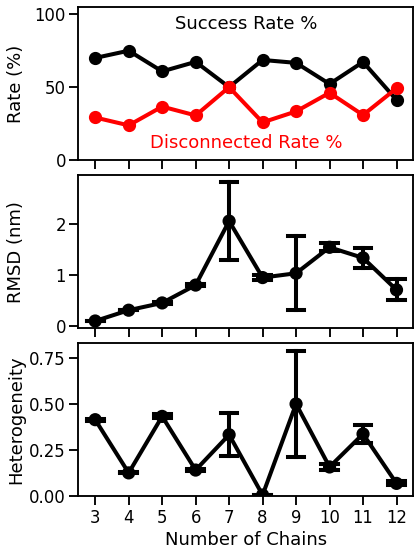

In [257]:
# Filter for chain size >= 3 and <= 12
df_size_filtered = df[(df['Number of chains in PDB'] >= 3) & (df['Number of chains in PDB'] <= 12)]
success_size_filtered = df_size_filtered[df_size_filtered['Status'] == 'Success']

fig, axes = plt.subplots(3, 1, figsize=(6, 9), sharex=True, gridspec_kw={'hspace': 0.1})

# Subplot 1: Success & Disconnected Rate by Size
def get_rates(x):
    return pd.Series({'Success Rate (%)': (x == 'Success').mean() * 100, 'Disconnected Rate (%)': (x == 'DC').mean() * 100})
rates_df = df_size_filtered.groupby('Number of chains in PDB')['Status'].apply(get_rates).unstack().reset_index()
rates_melted = rates_df.melt(id_vars=['Number of chains in PDB'], value_vars=['Success Rate (%)', 'Disconnected Rate (%)'], var_name='Metric', value_name='Rate (%)')
sns.pointplot(
    data=rates_melted, 
    x='Number of chains in PDB', 
    y='Rate (%)', 
    hue='Metric',
    markers=['o', 'o'], 
    linestyles=['-', '-'], 
    palette={'Success Rate (%)': 'black', 'Disconnected Rate (%)': 'red'},
    ax=axes[0]
)
axes[0].set_ylabel('Rate (%)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 105)
axes[0].get_legend().remove()
axes[0].text(0.5, 0.95, 'Success Rate %', transform=axes[0].transAxes, ha='center', va='top', color='black')
axes[0].text(0.5, 0.05, 'Disconnected Rate %', transform=axes[0].transAxes, ha='center', va='bottom', color='red')

# Subplot 2: RMSD
sns.pointplot(
    data=success_size_filtered, 
    x='Number of chains in PDB', 
    y='RMSD', 
    errorbar='se', 
    capsize=0.5, 
    markers='o', 
    color='black',
    ax=axes[1]
)
axes[1].set_ylabel('RMSD (nm)')
axes[1].set_xlabel('')

# Subplot 3: Heterogeneity
sns.pointplot(
    data=success_size_filtered, 
    x='Number of chains in PDB', 
    y='Heterogeneity', 
    errorbar='se', 
    capsize=0.5, 
    markers='o', 
    color='black',
    ax=axes[2]
)
axes[2].set_ylabel('Heterogeneity')
axes[2].set_xlabel('Number of Chains')
axes[2].set_ylim(ymin=0)

fig.align_ylabels()
plt.tight_layout()
plt.show()


### Combined Plots (Extended Rates & Grouped RMSD)

/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_38599/425051298.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


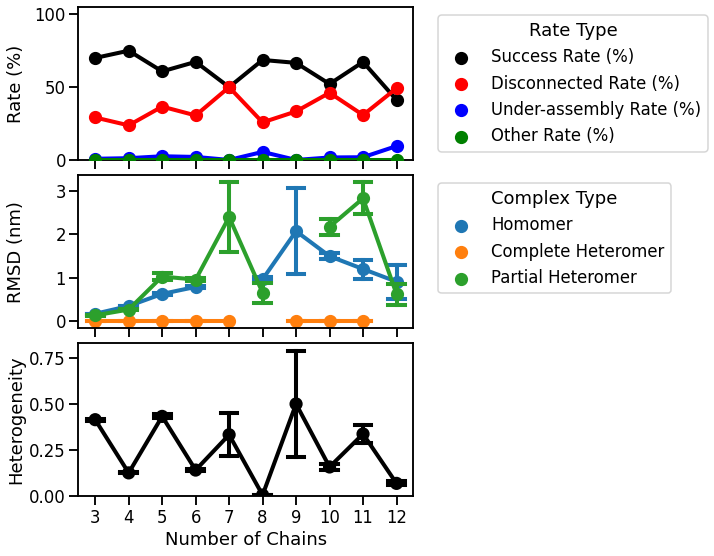

In [258]:
# Filter for chain size >= 3 and <= 12
df_size_filtered = df[(df['Number of chains in PDB'] >= 3) & (df['Number of chains in PDB'] <= 12)]
success_size_filtered = df_size_filtered[df_size_filtered['Status'] == 'Success']

fig, axes = plt.subplots(3, 1, figsize=(6, 9), sharex=True, gridspec_kw={'hspace': 0.1})

# Subplot 1: Success, Disconnected, Under-assembly, Other Rate by Size
def get_rates_all(x):
    return pd.Series({'Success Rate (%)': (x == 'Success').mean() * 100, 
                      'Disconnected Rate (%)': (x == 'DC').mean() * 100, 
                      'Under-assembly Rate (%)': (x == 'UA').mean() * 100, 
                      'Other Rate (%)': (x == 'FP').mean() * 100})
rates_df = df_size_filtered.groupby('Number of chains in PDB')['Status'].apply(get_rates_all).unstack().reset_index()
rates_melted = rates_df.melt(id_vars=['Number of chains in PDB'], value_vars=['Success Rate (%)', 'Disconnected Rate (%)', 'Under-assembly Rate (%)', 'Other Rate (%)'], var_name='Metric', value_name='Rate (%)')
sns.pointplot(
    data=rates_melted,
    x='Number of chains in PDB',
    y='Rate (%)',
    hue='Metric',
    markers=['o', 'o', 'o', 'o'],
    linestyles=['-', '-', '-', '-'],
    palette={'Success Rate (%)': 'black', 'Disconnected Rate (%)': 'red', 'Under-assembly Rate (%)': 'blue', 'Other Rate (%)': 'green'},
    ax=axes[0]
)
axes[0].set_ylabel('Rate (%)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 105)
axes[0].legend(title='Rate Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Subplot 2: RMSD grouped by Complex Type
sns.pointplot(
    data=success_size_filtered,
    x='Number of chains in PDB',
    y='RMSD',
    hue='Complex_Type',
    errorbar='se',
    capsize=0.5,
    ax=axes[1]
)
axes[1].set_ylabel('RMSD (nm)')
axes[1].set_xlabel('')
axes[1].legend(title='Complex Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Subplot 3: Heterogeneity
sns.pointplot(
    data=success_size_filtered,
    x='Number of chains in PDB',
    y='Heterogeneity',
    errorbar='se',
    capsize=0.5,
    markers='o',
    color='black',
    ax=axes[2]
)
axes[2].set_ylabel('Heterogeneity')
axes[2].set_xlabel('Number of Chains')
axes[2].set_ylim(ymin=0)

fig.align_ylabels()
plt.tight_layout()
plt.show()


### Grouped Stacked Plot: Rates, RMSD (by Complex Type), and Heterogeneity vs Number of Chains


/var/folders/sb/kq7xx1cx5cq2j75_xd4w1nd40000gn/T/ipykernel_38599/1235920084.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


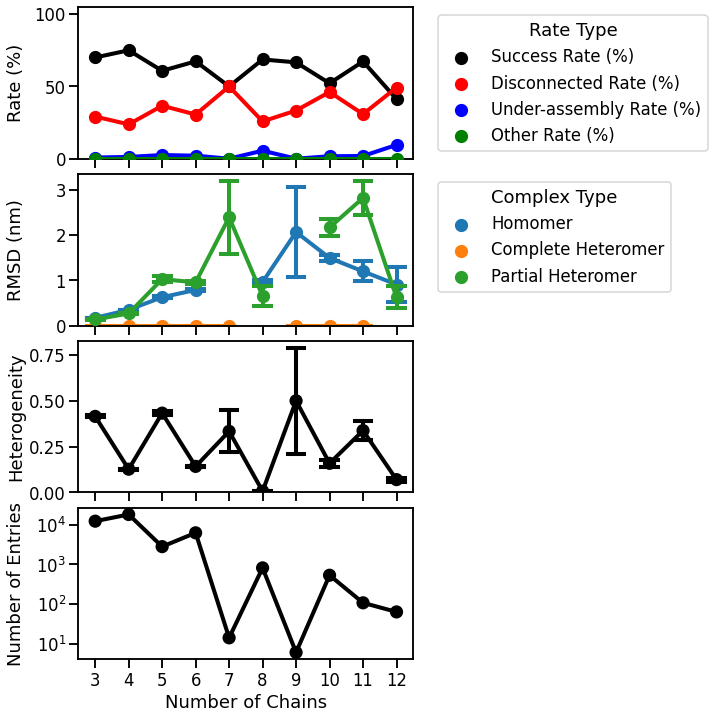

In [259]:
# Filter for chain size >= 3 and <= 12
df_size_filtered = df[(df['Number of chains in PDB'] >= 3) & (df['Number of chains in PDB'] <= 12)]
success_size_filtered = df_size_filtered[df_size_filtered['Status'] == 'Success']

fig, axes = plt.subplots(4, 1, figsize=(6, 12), sharex=True, gridspec_kw={'hspace': 0.1})

# Subplot 1: Success, Disconnected, Under-assembly, Other Rate by Size
def get_rates_all(x):
    return pd.Series({'Success Rate (%)': (x == 'Success').mean() * 100, 
                      'Disconnected Rate (%)': (x == 'DC').mean() * 100, 
                      'Under-assembly Rate (%)': (x == 'UA').mean() * 100, 
                      'Other Rate (%)': (x == 'FP').mean() * 100})
rates_df = df_size_filtered.groupby('Number of chains in PDB')['Status'].apply(get_rates_all).unstack().reset_index()
rates_melted = rates_df.melt(id_vars=['Number of chains in PDB'], value_vars=['Success Rate (%)', 'Disconnected Rate (%)', 'Under-assembly Rate (%)', 'Other Rate (%)'], var_name='Metric', value_name='Rate (%)')
sns.pointplot(
    data=rates_melted,
    x='Number of chains in PDB',
    y='Rate (%)',
    hue='Metric',
    markers=['o', 'o', 'o', 'o'],
    linestyles=['-', '-', '-', '-'],
    palette={'Success Rate (%)': 'black', 'Disconnected Rate (%)': 'red', 'Under-assembly Rate (%)': 'blue', 'Other Rate (%)': 'green'},
    ax=axes[0]
)
axes[0].set_ylabel('Rate (%)')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 105)
axes[0].legend(title='Rate Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Subplot 2: RMSD grouped by Complex Type
sns.pointplot(
    data=success_size_filtered,
    x='Number of chains in PDB',
    y='RMSD',
    hue='Complex_Type',
    errorbar='se',
    capsize=0.5,
    ax=axes[1]
)
axes[1].set_ylabel('RMSD (nm)')
axes[1].set_ylim(ymin=0)
axes[1].set_xlabel('')
axes[1].legend(title='Complex Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Subplot 3: Heterogeneity
sns.pointplot(
    data=success_size_filtered,
    x='Number of chains in PDB',
    y='Heterogeneity',
    errorbar='se',
    capsize=0.5,
    markers='o',
    color='black',
    ax=axes[2]
)
axes[2].set_ylabel('Heterogeneity')
axes[2].set_xlabel('')
axes[2].set_ylim(ymin=0)

# Subplot 4: Number of Entries
counts_df = df_size_filtered.groupby('Number of chains in PDB').size().reset_index(name='Entries')
sns.pointplot(
    data=counts_df,
    x='Number of chains in PDB',
    y='Entries',
    color='black',
    markers='o',
    ax=axes[3]
)
axes[3].set_ylabel('Number of Entries')
axes[3].set_yscale('log')
axes[3].set_yticks([10, 100, 1000, 10000])
axes[3].set_xlabel('Number of Chains')

fig.align_ylabels()
plt.tight_layout()
plt.show()


### 3. Success rate by size plot, classified by homomer, partial heteromer, and complete heteromer

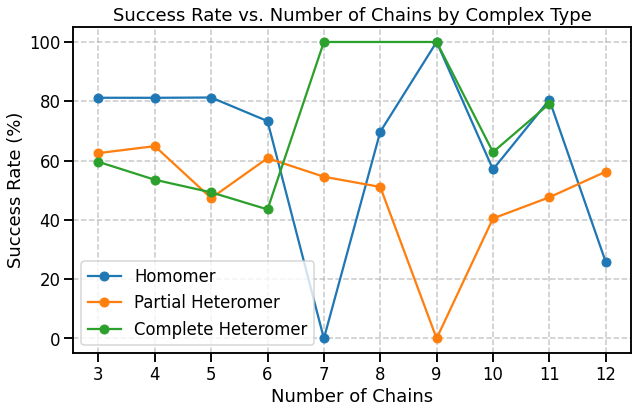

In [260]:
plt.figure(figsize=(10, 6))
for ctype in ['Homomer', 'Partial Heteromer', 'Complete Heteromer']:
    sub_df = df_filtered[df_filtered['Complex_Type'] == ctype]
    if not sub_df.empty:
        success_rate = sub_df.groupby('Number of chains in PDB')['Status'].apply(lambda x: (x == 'Success').mean() * 100)
        plt.plot(success_rate.index, success_rate.values, marker='o', linestyle='-', label=ctype)

plt.xlabel('Number of Chains')
plt.ylabel('Success Rate (%)')
plt.title('Success Rate vs. Number of Chains by Complex Type')
plt.xticks(range(3, 13))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 4. RMSD vs number of chains (size 3-12), with errorbar showing 1 SE, grouped by type

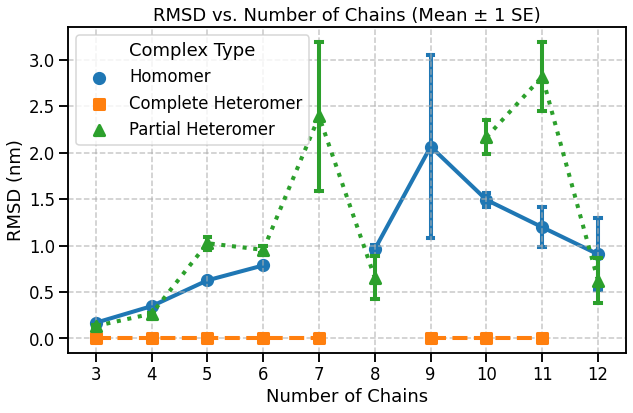

In [261]:
plt.figure(figsize=(10, 6))
success_filtered = df_filtered[df_filtered['Status'] == 'Success']

sns.pointplot(
    data=success_filtered, 
    x='Number of chains in PDB', 
    y='RMSD', 
    hue='Complex_Type',
    errorbar='se', 
    capsize=0.1, 
    markers=['o', 's', '^'], 
    linestyles=['-', '--', ':']
)

plt.xlabel('Number of Chains')
plt.ylabel('RMSD (nm)')
plt.title('RMSD vs. Number of Chains (Mean ± 1 SE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Complex Type')
plt.show()

### 5. RMSD scatter plot: RMSD vs homogenity (Success only)

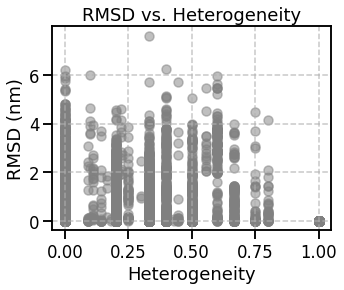

In [262]:
plt.figure(figsize=(5, 3.75))
plt.scatter(success_df['Heterogeneity'], success_df['RMSD'], alpha=0.5, color='gray')
plt.xlabel('Heterogeneity')
plt.ylabel('RMSD (nm)')
plt.title('RMSD vs. Heterogeneity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 6. RMSD scatter plot: RMSD vs homogenity (Success only) colorcoded

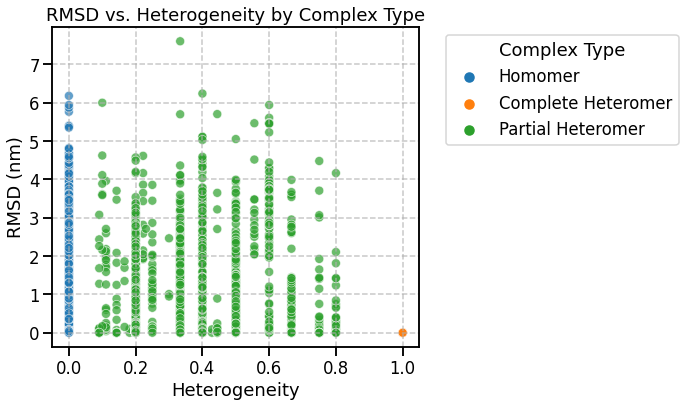

In [263]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=success_df, x='Heterogeneity', y='RMSD', hue='Complex_Type', alpha=0.7)
plt.xlabel('Heterogeneity')
plt.ylabel('RMSD (nm)')
plt.title('RMSD vs. Heterogeneity by Complex Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Complex Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 7. RMSD vs homogenity (Mean ± 1 SE by Complex Type)

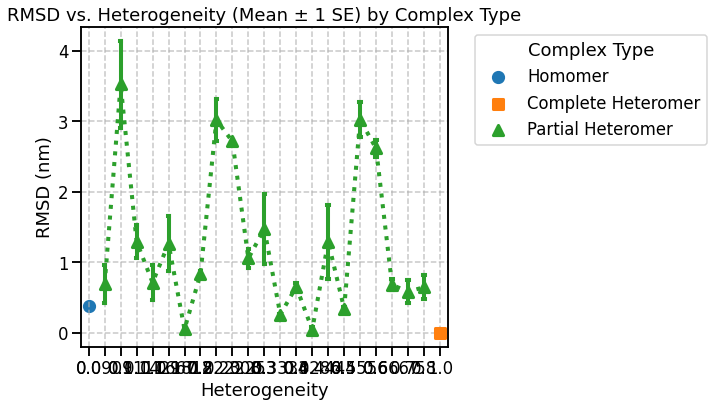

In [264]:
plt.figure(figsize=(10, 6))
success_df_plot = success_df.copy()
success_df_plot['Heterogeneity'] = success_df_plot['Heterogeneity'].round(4)

sns.pointplot(
    data=success_df_plot, 
    x='Heterogeneity', 
    y='RMSD', 
    hue='Complex_Type',
    errorbar='se', 
    capsize=0.1, 
    markers=['o', 's', '^'], 
    linestyles=['-', '--', ':']
)

plt.xlabel('Heterogeneity')
plt.ylabel('RMSD (nm)')
plt.title('RMSD vs. Heterogeneity (Mean ± 1 SE) by Complex Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Complex Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 8. RMSD vs homogenity (Mean ± 1 SE Overall)

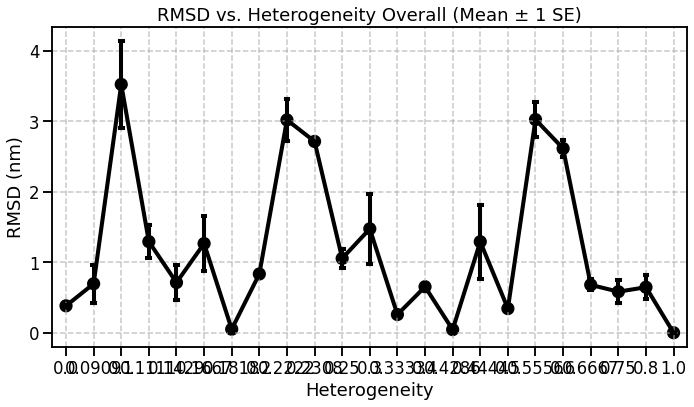

In [265]:
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=success_df_plot, 
    x='Heterogeneity', 
    y='RMSD', 
    errorbar='se', 
    capsize=0.1, 
    markers='o', 
    color='black'
)

plt.xlabel('Heterogeneity')
plt.ylabel('RMSD (nm)')
plt.title('RMSD vs. Heterogeneity Overall (Mean ± 1 SE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()